In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import locale, matplotlib
locale.setlocale(locale.LC_ALL, 'ru_RU')
matplotlib.rcParams['axes.formatter.use_locale'] = True


t_net_filtering = np.array([4. * i for i in range(25)])

In [4]:
import pickle 

id1 = 'example_for_arc_v12_one_jump'
id2 = 'example_for_arc_v12_two_jumps'

with open('saved_path_' + id1 + '/rmse_10000_paths/res_theta.pkl', 'rb') as f:
    res_theta1 = pickle.load(f)

with open('saved_path_' + id1 + '/rmse_10000_paths/res_y.pkl', 'rb') as f:
    res_y1 = pickle.load(f)

with open('saved_path_' + id2 + '/rmse_10000_paths/res_theta.pkl', 'rb') as f:
    res_theta2 = pickle.load(f)

with open('saved_path_' + id2 + '/rmse_10000_paths/res_y.pkl', 'rb') as f:
    res_y2 = pickle.load(f)

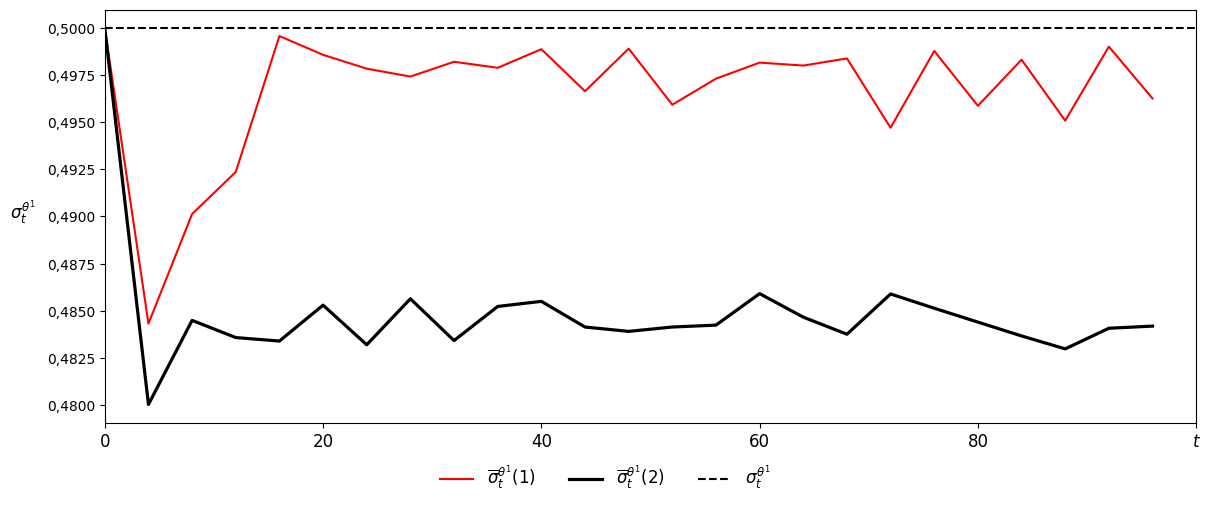

In [5]:
fig, ax = plt.subplots( figsize=(12, 5), layout='constrained')

ax.plot(t_net_filtering, np.sqrt(res_theta1[:, 0]), 
        color='red',
        label='$\\overline{\\sigma}_t^{\\theta^1}(1)$',
)
ax.plot(t_net_filtering, np.sqrt(res_theta2[:, 0]), 
        color='k',
        label='$\\overline{\\sigma}_t^{\\theta^1}(2)$', 
        lw=2.3
)
# ax.plot(t_net_filtering, np.sqrt(res_theta3[:, 0]), 
#         color='blue',
#         label='$\\hat{\\sigma}^{\\theta}(1), n = 10$',
# )
# ax.plot(t_net_filtering, np.sqrt(res_theta4[:, 0]), 
#         color='darkgreen',
#         label='$\\hat{\\sigma}^{\\theta}(2), n = 10$', 
#         lw=2.3
# )
ax.axhline(0.5, ls='--', color='k', label='$\\sigma_t^{\\theta^1}$')

ax.set_ylabel('$\\sigma_t^{\\theta^1}$', rotation='horizontal', fontsize=12)
ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=12,
)
ax.yaxis.set_label_coords(-0.075, 0.475)

#ax.set_yscale('log')

fig.legend(
    loc='outside lower center',
    ncols=5,
    fontsize=12,
    frameon=False
)

plt.show()

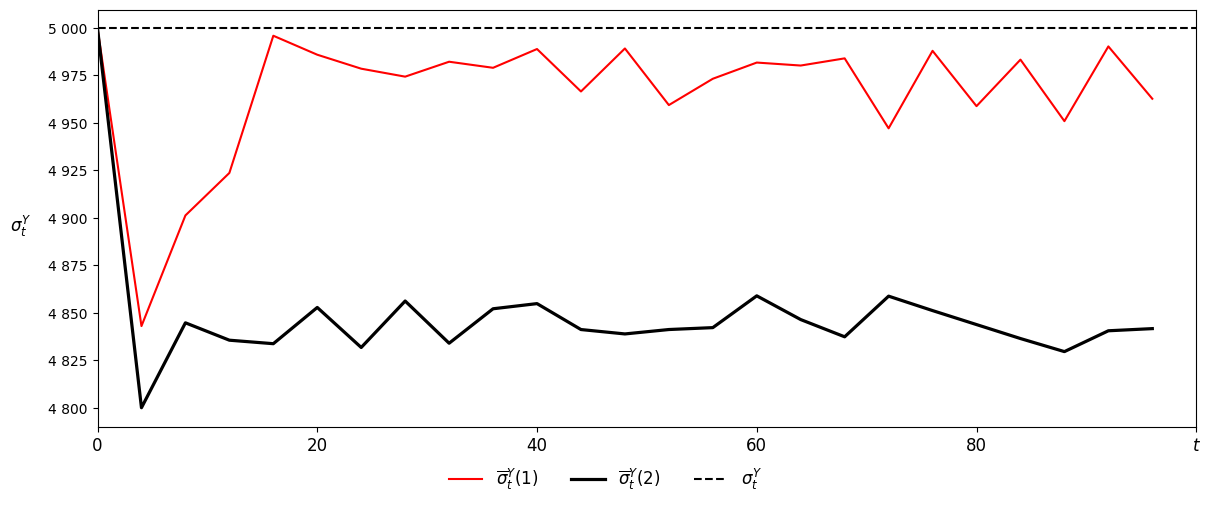

In [6]:
fig, ax = plt.subplots(1, figsize=(12, 5), layout='constrained')

ax.plot(t_net_filtering, np.sqrt(res_y1[:, 0]), color='red', label='$\\overline{\\sigma}_t^{Y}(1)$',)
ax.plot(t_net_filtering, np.sqrt(res_y2[:, 0]), color='k', label='$\\overline{\\sigma}_t^{Y}(2)$', lw=2.3)
# ax.plot(t_net_filtering, np.sqrt(res_y3[:, 0]), color='blue', label='$\\hat{\\sigma}^Y(1), n = 10$',)
# ax.plot(t_net_filtering, np.sqrt(res_y4[:, 0]), color='darkgreen', label='$\\hat{\\sigma}^Y(2), n = 10$', lw=2.3)
ax.axhline(5000, color='k', ls='--', label='$\\sigma_t^{Y}$',)

ax.set_ylabel('$\\sigma_t^{Y}$', rotation='horizontal', fontsize=12)
ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=12,
)
ax.yaxis.set_label_coords(-0.07, 0.45)

#ax.set_yscale('log')
fig.legend(
    loc='outside lower center',
    ncols=5,
    fontsize=12,
    frameon=False
)
plt.show()

In [7]:
(res_y1 >= res_y2).sum(), (res_theta1[:, 0] >= res_theta2[:, 0]).sum()

(np.int64(25), np.int64(25))